In [5]:
# Cell 1: Setup and imports
%env XLA_PYTHON_CLIENT_PREALLOCATE=False
import jax
jax.config.update("jax_enable_x64", False)
import jax.numpy as jnp
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np

DIRS = ["./power2WFgreedy/heavyfactor09_2"]
data = {}
for DIR in DIRS:
    data[DIR] = {}
    for file in os.listdir(DIR):
        if file.endswith(".pkl") and file.startswith("__"):
            with open(os.path.join(DIR, file), "rb") as f:
                my_pkl = pickle.load(f)
            eps = my_pkl['config']['eps']
            if eps in data[DIR]:
                _data = data[DIR][eps]
            else:
                _data = {}
            if "particles" in _data.keys():
                _data["particles"] = jnp.concatenate([_data["particles"], my_pkl['res'][0][:,-1]], axis=0)
                _data["log_weights"] = jnp.concatenate([_data["log_weights"],  my_pkl['res'][1][:,-1]], axis=0)
                _data["temperatures"] = jnp.concatenate([_data["temperatures"],  my_pkl['res'][2]], axis=0)
            else:
                _data["particles"] = my_pkl['res'][0][:,-1]
                _data["log_weights"] = my_pkl['res'][1][:,-1]
                _data["temperatures"] = my_pkl['res'][2]
        data[DIR][eps] = _data.copy()
f_tests = [lambda x: jnp.sum(jnp.sin(x)**2, axis=-1), lambda x: jnp.sin(x[...,0])**2]

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [4]:
my_pkl['res'][2]

Array([[1.],
       [1.]], dtype=float32)

In [ ]:
data[DIR].keys()

In [54]:
jnp.mean((f_tests[-1])(data['./power2WFgreedy/heavyfactor4']['particles'][:,4]), axis=[-1, -2])

W0322 11:26:00.671986   71938 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200 NVL. Using default config.


Array([4.050446 , 4.042445 , 4.051317 , 4.047688 , 4.0517197, 4.05029  ,
       4.0547285, 4.0508204, 4.0518584, 4.044894 , 4.0490546, 4.0464087,
       4.0490203, 4.0517993, 4.0546713, 4.0492663, 4.053499 , 4.046697 ,
       4.053063 , 4.0457697, 4.0508957, 4.053966 , 4.051738 , 4.0514793,
       4.054803 , 4.04977  , 4.052801 , 4.0465403, 4.0498104, 4.053832 ,
       4.0468383, 4.0573454, 4.046387 , 4.0493116, 4.0424466, 4.0500607,
       4.050201 , 4.0480723, 4.0501723, 4.053349 , 4.0573325, 4.0488434,
       4.0554643, 4.057308 , 4.0526814, 4.042046 , 4.060877 , 4.0432606,
       4.0394773, 4.0525737, 4.0435724, 4.0525374, 4.0549226, 4.0417476,
       4.053461 , 4.0559883, 4.053985 , 4.04191  , 4.0536823, 4.0514774,
       4.049014 , 4.0498796, 4.0620046, 4.0438733, 4.051045 , 4.0462437,
       4.048326 , 4.056628 , 4.050735 , 4.0543184, 4.0513067, 4.055138 ,
       4.044889 , 4.0474176, 4.04959  , 4.0467534, 4.0425754, 4.0487933,
       4.0559483, 4.047574 , 4.0502653, 4.0486684, 

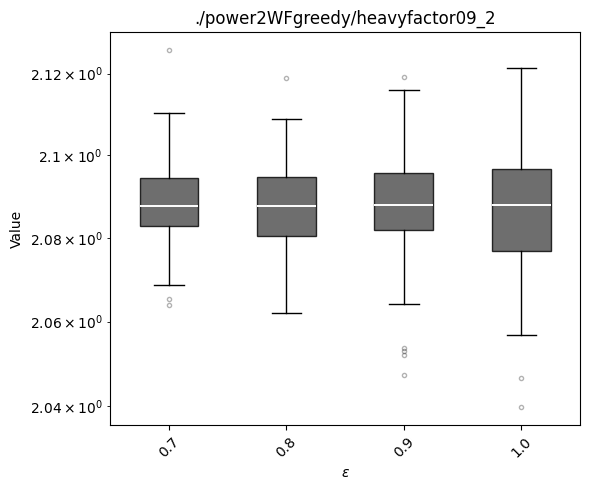

In [7]:
# Cell 2: One figure per DIR, one box per epsilon

titles = {
    "./power2WFgreedy/heavyfactor09": "Heavy-tailed (greedy)",
    #"./power2WFgreedy/heavyfactor05": "Light-tailed (greedy)"
}

for DIR in DIRS:

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))

    # --- Get and sort epsilons ---
    eps_list = sorted(data[DIR].keys())

    box_data = []

    for eps in eps_list:
        particles = data[DIR][eps]["particles"]

        # --- Compute values for this epsilon ---
        vals = jnp.mean(
            (f_tests[0])(particles),
            axis=[-1, -2]
        )
        vals = np.array(vals).squeeze()

        box_data.append(vals)

    # --- Positions ---
    positions = range(len(eps_list))

    common_props = dict(linewidth=1)

    b1 = ax.boxplot(
        box_data,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor="#4a4a4a", edgecolor="black", alpha=0.8, **common_props),
        medianprops=dict(color="white", linewidth=1.4),
        whiskerprops=dict(color="black", **common_props),
        capprops=dict(color="black", **common_props),
        flierprops=dict(marker='o', markersize=3, alpha=0.3)
    )

    # --- Formatting ---
    ax.set_xticks(list(positions))
    ax.set_xticklabels([str(eps) for eps in eps_list], rotation=45)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel("Value")
    ax.set_yscale("log")
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_title(titles.get(DIR, DIR))

    plt.tight_layout()
    plt.savefig(DIR.replace("/", "_") + "_boxplots_eps.pdf", dpi=300)
    plt.show()

In [3]:
vals

array(4.3581724, dtype=float32)

In [16]:
data[DIR][eps]["temperatures"]

Array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1